In [1]:
# =========================================================
# FAKE NEWS DETECTION USING NLP AND MACHINE LEARNING
# =========================================================

# STEP 1 - IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# STEP 2 - LOAD DATASETS

# Load fake news dataset
fake_df = pd.read_csv(
    "Fake.csv",
    on_bad_lines='skip',
    engine='python'
)

# Load true news dataset
true_df = pd.read_csv(
    "True.csv",
    on_bad_lines='skip',
    engine='python'
)

# Add labels
fake_df["label"] = "FAKE"
true_df["label"] = "REAL"

# Combine datasets
df = pd.concat([fake_df, true_df])

# Shuffle dataset
df = df.sample(frac=1, random_state=42)

# Reset index
df.reset_index(drop=True, inplace=True)

# Display dataset
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",FAKE
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",REAL
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",REAL
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",FAKE
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",REAL


In [4]:
# STEP 3 - KEEP REQUIRED COLUMNS

df = df[['text', 'label']]

# Display dataset
df.head()

,text,label
0,"21st Century Wire says Ben Stein, reputable pr...",FAKE
1,WASHINGTON (Reuters) - U.S. President Donald T...,REAL
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,REAL
3,"On Monday, Donald Trump once again embarrassed...",FAKE
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",REAL


In [5]:
# STEP 4 - DATASET INFORMATION

print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nLabel Count:")
print(df['label'].value_counts())

Dataset Shape:
(44898, 2)

Missing Values:
text     0
label    0
dtype: int64

Label Count:
label
FAKE    23481
REAL    21417
Name: count, dtype: int64


In [6]:
# STEP 5 - DATA CLEANING

import re
import string

def clean_text(text):

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\\S+', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove numbers
    text = re.sub(r'\\d+', '', text)

    return text

In [7]:
# Apply cleaning function

df['text'] = df['text'].apply(clean_text)

# Display cleaned text
df.head()

,text,label
0,21st century wire says ben stein reputable pro...,FAKE
1,washington reuters us president donald trump ...,REAL
2,reuters puerto rico governor ricardo rossello...,REAL
3,on monday donald trump once again embarrassed ...,FAKE
4,glasgow scotland reuters most us presidential...,REAL


In [8]:
# STEP 6 - SPLIT FEATURES AND LABELS

X = df['text']
y = df['label']

from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (31428,)
Testing Data: (13470,)


In [9]:
# STEP 7 - TF-IDF VECTORIZATION

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.7
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Vectorization Completed")

Vectorization Completed


In [10]:
# STEP 8 - IMPORT MACHINE LEARNING MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [11]:
# STEP 9 - TRAIN MACHINE LEARNING MODELS

models = {

    "Logistic Regression": LogisticRegression(),

    "Naive Bayes": MultinomialNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        random_state=42
    )
}

accuracy_results = {}

print("MODEL ACCURACY\n")

for model_name, model in models.items():

    # Train model
    model.fit(X_train_tfidf, y_train)

    # Predict
    y_pred = model.predict(X_test_tfidf)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    accuracy_results[model_name] = accuracy

    print(
        model_name,
        ":",
        round(accuracy * 100, 2),
        "%"
    )

MODEL ACCURACY

Logistic Regression : 98.23 %
Naive Bayes : 93.59 %
Random Forest : 98.34 %


In [12]:
# STEP 10 - FIND BEST MODEL

best_model_name = max(
    accuracy_results,
    key=accuracy_results.get
)

print("Best Model :", best_model_name)

best_model = models[best_model_name]

Best Model : Random Forest


In [13]:
# STEP 11 - MODEL EVALUATION

# Predict using best model
y_pred = best_model.predict(X_test_tfidf)

print("Classification Report\n")

print(classification_report(y_test, y_pred))

Classification Report

              precision    recall  f1-score   support

        FAKE       0.98      0.98      0.98      7065
        REAL       0.98      0.98      0.98      6405

    accuracy                           0.98     13470
   macro avg       0.98      0.98      0.98     13470
weighted avg       0.98      0.98      0.98     13470



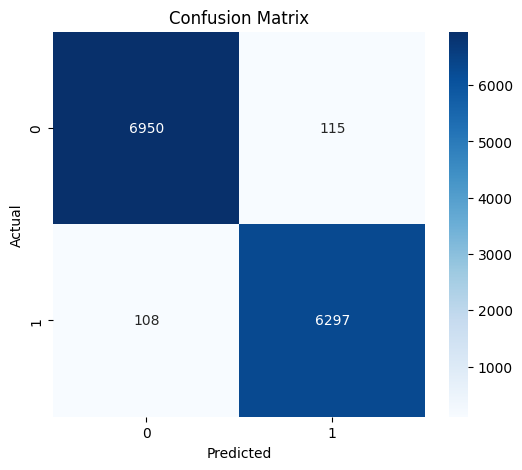

In [14]:
# STEP 12 - CONFUSION MATRIX

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [15]:
# STEP 13 - MODEL ACCURACY COMPARISON

accuracy_df = pd.DataFrame({

    "Model": accuracy_results.keys(),
    "Accuracy": accuracy_results.values()
})

accuracy_df

,Model,Accuracy
0,Logistic Regression,0.982331
1,Naive Bayes,0.935857
2,Random Forest,0.983445


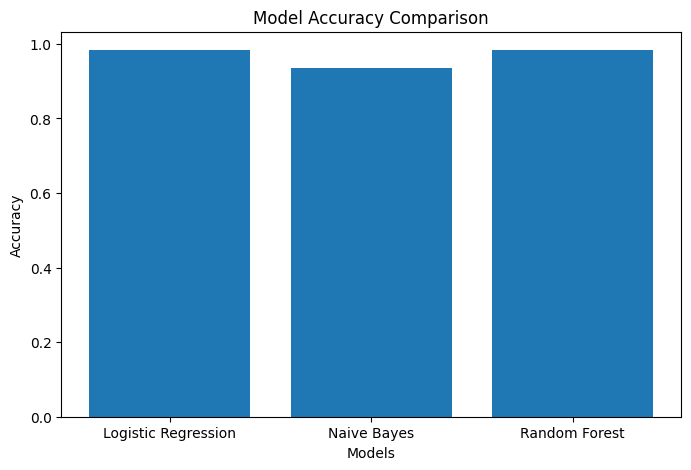

In [16]:
# Accuracy Comparison Graph

plt.figure(figsize=(8,5))

plt.bar(
    accuracy_df["Model"],
    accuracy_df["Accuracy"]
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

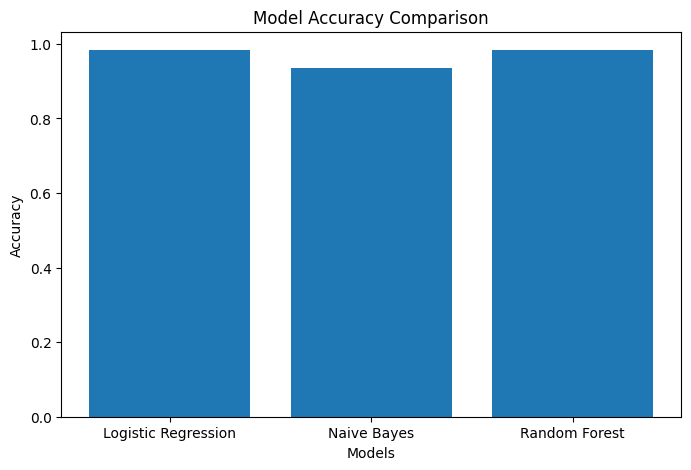

In [17]:
# Accuracy Comparison Graph

plt.figure(figsize=(8,5))

plt.bar(
    accuracy_df["Model"],
    accuracy_df["Accuracy"]
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

In [27]:
# STEP 14 - TEST WITH MULTIPLE NEWS SAMPLES

sample_news_list = [

    # News 1
    """
    The article discusses how U.S. Interior Secretary
Ryan Zinke launched an initiative to reduce the
country’s dependence on foreign supplies of
critical minerals used in smartphones, computers,
batteries, and military equipment.

Under President Donald Trump’s directive, the
U.S. government planned to identify vulnerable
minerals, increase domestic mining and recycling,
improve geological data access, and streamline
mining permits.

The initiative was considered important because
the United States heavily depended on countries
like China and Russia for essential minerals,
creating economic and national security risks.
    """,

    # News 2
    """
    Aliens have landed in New York City
    and started communicating with humans.
    """,

    # News 3
    """
    The government announced new education
    policies to improve digital learning.
    """,

    # News 4
    """
    Drinking only coffee for 30 days
    guarantees weight loss without exercise.
    """
]

print("FAKE NEWS DETECTION RESULTS\n")

for i, news in enumerate(sample_news_list):

    # Clean text
    cleaned_news = clean_text(news)

    # Convert into vector
    news_vector = vectorizer.transform([cleaned_news])

    # Predict
    prediction = best_model.predict(news_vector)

    print(f"News {i+1} Prediction :", prediction[0])
    print("-" * 50)

FAKE NEWS DETECTION RESULTS

News 1 Prediction : REAL
--------------------------------------------------
News 2 Prediction : FAKE
--------------------------------------------------
News 3 Prediction : FAKE
--------------------------------------------------
News 4 Prediction : FAKE
--------------------------------------------------
